<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Sesiones/Sesion07_bDatos_Ising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Modelo de Ising 2D: generación de datos para clasificación con redes neuronales

Construiremos el proyecto por partes:

1. **Geometría de la red** (esta sección): red cuadrada $L\times L$ parametrizable, con condiciones de frontera periódicas o libres, y visualización.
2. Asignación de espines aleatorios ($s_i = \pm 1$) sobre la red.
3. Dinámica de Monte Carlo (algoritmo de Metropolis) para muestrear el equilibrio térmico.
4. Cálculo de observables por sitio en función de la temperatura: magnetización, susceptibilidad y calor específico.
5. Generación del dataset (configuraciones de espines etiquetadas por fase/temperatura) para entrenar una red neuronal clasificadora.

## 1. Geometría de la red

Definimos una red cuadrada de $L \times L$ sitios. Cada sitio $s$ tiene coordenadas $(i, j)$ con $i, j \in \{0, \dots, L-1\}$, e índice lineal $s = i \cdot L + j$.

La conectividad (vecinos más cercanos: arriba, abajo, izquierda, derecha) depende de la **condición de frontera**:

- **Periódica**: la red se enrolla sobre sí misma (topología de toro). El sitio en el borde derecho es vecino del sitio en el borde izquierdo de la misma fila, y análogamente para arriba/abajo. Todos los sitios tienen exactamente 4 vecinos.
- **Libre** (abierta): no hay conexión entre bordes opuestos. Los sitios de esquina tienen 2 vecinos, los de borde 3, y los interiores 4.

La clase `RedIsing2D` construye esta geometría de forma parametrizable en `L` y `frontera`, y permite visualizarla.

In [216]:
import numpy as np
import matplotlib.pyplot as plt

In [217]:
class RedIsing2D:
    """
    Geometria de una red cuadrada LxL para el modelo de Ising.

    Parametros
    ----------
    L : int
        Tamano lineal de la red (numero de sitios por lado). Se recomienda L >= 3.
    frontera : str
        Condicion de frontera: 'periodica' o 'libre'.
    """

    def __init__(self, L, frontera='periodica'):
        if frontera not in ('periodica', 'libre'):
            raise ValueError("frontera debe ser 'periodica' o 'libre'")
        self.L = L
        self.N = L * L
        self.frontera = frontera
        self.vecinos, self._direcciones = self._construir_vecinos()

    def indice(self, i, j):
        """Coordenadas (fila, columna) -> indice lineal 0..N-1."""
        return i * self.L + j

    def coordenadas(self, s):
        """Indice lineal -> coordenadas (fila, columna)."""
        return divmod(s, self.L)

    def _construir_vecinos(self):
        L = self.L
        vecinos = {}
        direcciones = {}
        for i in range(L):
            for j in range(L):
                s = self.indice(i, j)
                if self.frontera == 'periodica':
                    d = {
                        'arriba': self.indice((i - 1) % L, j),
                        'abajo': self.indice((i + 1) % L, j),
                        'izquierda': self.indice(i, (j - 1) % L),
                        'derecha': self.indice(i, (j + 1) % L),
                    }
                else:  # libre
                    d = {
                        'arriba': self.indice(i - 1, j) if i - 1 >= 0 else None,
                        'abajo': self.indice(i + 1, j) if i + 1 < L else None,
                        'izquierda': self.indice(i, j - 1) if j - 1 >= 0 else None,
                        'derecha': self.indice(i, j + 1) if j + 1 < L else None,
                    }
                direcciones[s] = d
                vecinos[s] = [v for v in d.values() if v is not None]
        return vecinos, direcciones

    def vecinos_de(self, s):
        """Devuelve el diccionario de vecinos por direccion (arriba/abajo/izquierda/derecha) del sitio s."""
        return self._direcciones[s]

    def tabla_vecinos(self):
        """Tabla completa de vecinos: un DataFrame con una fila por sitio y sus vecinos por direccion.

        Permite consultar un sitio puntual con, por ejemplo, `tabla.loc[10]`.
        """
        import pandas as pd
        filas = []
        for s in range(self.N):
            i, j = self.coordenadas(s)
            d = self._direcciones[s]
            filas.append({
                'sitio': s,
                'fila': i,
                'columna': j,
                'arriba': d['arriba'],
                'abajo': d['abajo'],
                'izquierda': d['izquierda'],
                'derecha': d['derecha'],
                'num_vecinos': len(self.vecinos[s]),
            })
        return pd.DataFrame(filas).set_index('sitio')

    def graficar(self, mostrar_indices=False, figsize=(5, 5), ax=None):
        """Dibuja los sitios de la red y los enlaces a primeros vecinos.

        Los enlaces que cruzan la frontera periodica (toro) se dibujan
        punteados y en otro color para distinguirlos de los enlaces normales.
        """
        L = self.L
        creado = False
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            creado = True

        enlaces_normales = set()
        enlaces_frontera = set()
        for s, vecs in self.vecinos.items():
            i, j = self.coordenadas(s)
            for v in vecs:
                vi, vj = self.coordenadas(v)
                enlace = frozenset((s, v))
                if abs(vi - i) > 1 or abs(vj - j) > 1:
                    enlaces_frontera.add(enlace)
                else:
                    enlaces_normales.add(enlace)

        for enlace in enlaces_normales:
            s, v = tuple(enlace)
            i, j = self.coordenadas(s)
            vi, vj = self.coordenadas(v)
            ax.plot([j, vj], [i, vi], '-', color='tab:blue', lw=1, alpha=0.7, zorder=1)

        for enlace in enlaces_frontera:
            s, v = tuple(enlace)
            i, j = self.coordenadas(s)
            vi, vj = self.coordenadas(v)
            ax.plot([j, vj], [i, vi], '--', color='tab:orange', lw=1, alpha=0.5, zorder=1)

        xs = [self.coordenadas(s)[1] for s in range(self.N)]
        ys = [self.coordenadas(s)[0] for s in range(self.N)]
        ax.scatter(xs, ys, color='black', s=60, zorder=2)

        if mostrar_indices:
            for s in range(self.N):
                i, j = self.coordenadas(s)
                ax.annotate(str(s), (j, i), textcoords='offset points', xytext=(5, 5), fontsize=8)

        ax.set_title(f'Red {L}x{L} — frontera {self.frontera}')
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_xticks(range(L))
        ax.set_yticks(range(L))

        if creado:
            plt.show()
        return ax

### Verificación: frontera periódica

Todos los sitios deben tener exactamente 4 vecinos.

In [218]:
red_periodica = RedIsing2D(L=6, frontera='periodica')
print(f"Numero de sitios: {red_periodica.N}")
print(f"Vecinos del sitio 0 (esquina superior izquierda): {red_periodica.vecinos[0]}")
print(f"Numero de vecinos por sitio (debe ser {{4}}): {set(len(v) for v in red_periodica.vecinos.values())}")

Numero de sitios: 36
Vecinos del sitio 0 (esquina superior izquierda): [30, 6, 5, 1]
Numero de vecinos por sitio (debe ser {4}): {4}


Para consultar los vecinos de un sitio puntual (por ejemplo el sitio 10) de forma clara, o inspeccionar la conectividad completa, usamos `tabla_vecinos()`, que devuelve un `DataFrame` indexado por sitio.

In [219]:
tabla_periodica = red_periodica.tabla_vecinos()
tabla_periodica

,fila,columna,arriba,abajo,izquierda,derecha,num_vecinos
sitio,,,,,,,
0,0,0,30,6,5,1,4
1,0,1,31,7,0,2,4
2,0,2,32,8,1,3,4
3,0,3,33,9,2,4,4
4,0,4,34,10,3,5,4
5,0,5,35,11,4,0,4
6,1,0,0,12,11,7,4
7,1,1,1,13,6,8,4
8,1,2,2,14,7,9,4


In [220]:
# Consultar un sitio puntual, p. ej. el sitio 10
tabla_periodica.loc[10]

fila            1
columna         4
arriba          4
abajo          16
izquierda       9
derecha        11
num_vecinos     4
Name: 10, dtype: int64

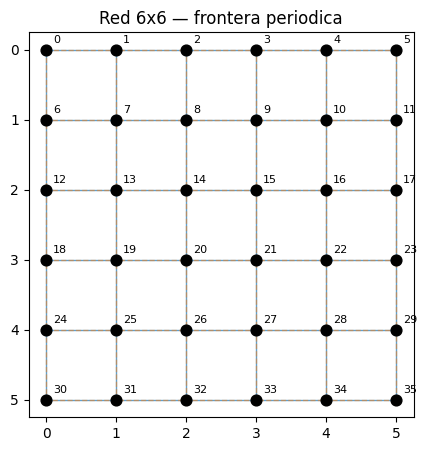

<Axes: title={'center': 'Red 6x6 — frontera periodica'}>

In [221]:
red_periodica.graficar(mostrar_indices=True)

### Verificación: frontera libre

El número de vecinos debe variar entre 2 (esquinas), 3 (bordes) y 4 (interior).

In [222]:
red_libre = RedIsing2D(L=6, frontera='libre')
print(f"Vecinos del sitio 0 (esquina superior izquierda): {red_libre.vecinos[0]}")
print(f"Numero de vecinos por sitio (varia entre 2, 3 y 4): {sorted(set(len(v) for v in red_libre.vecinos.values()))}")

Vecinos del sitio 0 (esquina superior izquierda): [6, 1]
Numero de vecinos por sitio (varia entre 2, 3 y 4): [2, 3, 4]


In [223]:
# En frontera libre, un sitio de borde/esquina tiene NaN en la(s) direccion(es) sin vecino
tabla_libre = red_libre.tabla_vecinos()
tabla_libre.loc[10]

fila            1.0
columna         4.0
arriba          4.0
abajo          16.0
izquierda       9.0
derecha        11.0
num_vecinos     4.0
Name: 10, dtype: float64

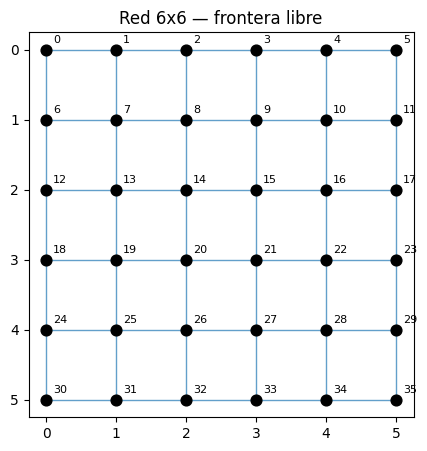

<Axes: title={'center': 'Red 6x6 — frontera libre'}>

In [224]:
red_libre.graficar(mostrar_indices=True)

Con la geometría lista (red parametrizable en `L` y en tipo de frontera, con visualización), el siguiente paso es **asignar espines aleatorios** $s_i \in \{-1, +1\}$ a cada sitio de la red.

## 2. Asignación de espines aleatorios

Con la geometría lista, asignamos a cada sitio $s$ un **espín** $s_i \in \{-1, +1\}$, donde $+1$ representa "arriba" ($\uparrow$) y $-1$ "abajo" ($\downarrow$).

En una configuración **aleatoria** cada sitio se decide de forma **independiente**: vale $+1$ con probabilidad $p$ y $-1$ con probabilidad $1-p$. Por defecto $p = 1/2$ (sin sesgo), lo que corresponde a un estado de temperatura infinita (desorden total).

La configuración se guarda como un vector `espines` de tamaño $N = L^2$, indexado por el índice lineal del sitio ($s = i\,L + j$); se puede reordenar como matriz $L\times L$ con `espines.reshape(L, L)`.

Un resumen escalar útil es la **magnetización por sitio**

$$m = \frac{1}{N}\sum_{i} s_i \in [-1, 1],$$

que para una configuración aleatoria sin sesgo cumple $m \approx 0$.

Esta configuración aleatoria será además el **punto de partida** de la dinámica de Monte Carlo (sección 3).

In [225]:
def asignar_espines_aleatorios(red, p_arriba=0.5, semilla=None):
    """
    Asigna a cada sitio de la red un espin aleatorio s_i en {-1, +1}.

    Cada sitio se decide de forma independiente: +1 ("arriba") con probabilidad
    p_arriba y -1 ("abajo") con probabilidad 1 - p_arriba.

    Parametros
    ----------
    red : RedIsing2D
        Geometria de la red (aporta el numero de sitios N).
    p_arriba : float
        Probabilidad de espin +1. Por defecto 0.5 (sin sesgo).
    semilla : int o None
        Semilla del generador aleatorio, para reproducibilidad.

    Devuelve
    --------
    espines : np.ndarray, forma (N,), dtype int8, valores en {-1, +1}
        Vector de espines indexado por el indice lineal del sitio (s = i*L + j).
    """
    rng = np.random.default_rng(semilla)
    espines = np.where(rng.random(red.N) < p_arriba, 1, -1).astype(np.int8)
    return espines


def magnetizacion_por_sitio(espines):
    """Magnetizacion por sitio: m = (1/N) sum_i s_i, en el rango [-1, 1]."""
    return float(np.mean(espines))

In [263]:
red = RedIsing2D(L=16, frontera='periodica')
espines = asignar_espines_aleatorios(red, p_arriba=0.5, semilla=42)

n_arriba = int((espines == 1).sum())
n_abajo = int((espines == -1).sum())
print(f"Red: {red.L}x{red.L} = {red.N} sitios, frontera {red.frontera}")
print(f"Espin +1 (arriba): {n_arriba} sitios")
print(f"Espin -1 (abajo) : {n_abajo} sitios")
print(f"Magnetizacion por sitio m = {magnetizacion_por_sitio(espines):+.4f}")
print()
print("Configuracion como matriz L x L (+1 / -1):")
print(espines.reshape(red.L, red.L))

Red: 16x16 = 256 sitios, frontera periodica
Espin +1 (arriba): 130 sitios
Espin -1 (abajo) : 126 sitios
Magnetizacion por sitio m = +0.0156

Configuracion como matriz L x L (+1 / -1):
[[-1  1 -1 -1  1 -1 -1 -1  1  1  1 -1 -1 -1  1  1]
 [-1  1 -1 -1 -1  1 -1 -1 -1  1  1  1  1 -1 -1 -1]
 [ 1  1  1  1  1  1  1 -1  1 -1 -1  1 -1 -1  1  1]
 [-1  1  1  1 -1 -1 -1 -1  1 -1  1  1 -1  1 -1 -1]
 [-1 -1 -1  1  1  1  1  1 -1  1  1  1  1 -1 -1 -1]
 [-1  1 -1  1  1  1 -1  1  1 -1  1 -1  1  1  1 -1]
 [ 1  1  1 -1 -1 -1  1 -1 -1 -1  1  1  1 -1  1  1]
 [ 1 -1  1 -1 -1 -1  1 -1 -1 -1  1  1  1  1  1  1]
 [ 1 -1  1 -1 -1  1 -1  1 -1  1 -1  1  1  1 -1 -1]
 [ 1  1  1 -1  1  1 -1 -1  1 -1  1 -1  1 -1 -1 -1]
 [ 1 -1  1  1 -1  1 -1 -1  1 -1  1 -1  1 -1  1  1]
 [ 1 -1 -1 -1 -1 -1 -1  1 -1 -1  1  1 -1  1 -1  1]
 [ 1 -1  1  1 -1 -1  1  1 -1 -1 -1  1  1  1  1 -1]
 [ 1 -1 -1 -1  1 -1 -1 -1  1  1 -1  1  1  1 -1 -1]
 [ 1 -1  1 -1 -1  1  1  1 -1 -1 -1 -1  1 -1  1  1]
 [-1 -1  1 -1 -1 -1 -1  1  1  1 -1 -1  1  1  1 -1]]

### Visualización

Dos vistas de la **misma** configuración:

1. **Red + espín**: cada sitio de la red se dibuja como un punto coloreado según su espín, con una flecha $\uparrow$ ($+1$) o $\downarrow$ ($-1$). Se ven a la vez la geometría y el valor de cada sitio; es útil para redes pequeñas.
2. **Blanco y negro**: la matriz $L\times L$ como imagen, con $+1$ en **blanco** y $-1$ en **negro**. Es la representación estándar de una configuración de Ising. A $L$ grande se aprecia la *textura*: una configuración aleatoria no tiene correlaciones espaciales, así que se ve como "ruido de nieve" (a diferencia de los dominios que aparecerán al termalizar con Monte Carlo).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

COLOR_ARRIBA = '#D55E00'
COLOR_ABAJO  = '#0072B2'


def graficar_configuracion(
    red,
    espines,
    con_enlaces=True,
    con_flechas=True,
    tam_flecha=0.55,
    ancho_flecha=0.018,
    tam_cabeza=4.5,
    figsize=(4, 4),
    ax=None
):

    L = red.L

    creado = ax is None

    if creado:
        fig, ax = plt.subplots(figsize=figsize)

    # Coordenadas
    ij = np.array(
        [red.coordenadas(s) for s in range(red.N)],
        dtype=float
    )

    yi = ij[:, 0]
    xj = ij[:, 1]

    # --------------------------------------------------
    # Enlaces
    # --------------------------------------------------
    if con_enlaces:

        vistos = set()

        for s, vecs in red.vecinos.items():

            si, sj = red.coordenadas(s)

            for v in vecs:

                clave = frozenset((s, v))

                if clave in vistos:
                    continue

                vistos.add(clave)

                vi, vj = red.coordenadas(v)

                # No dibujar enlaces que cruzan
                # la frontera periódica
                if abs(vi - si) > 1 or abs(vj - sj) > 1:
                    continue

                ax.plot(
                    [sj, vj],
                    [si, vi],
                    color='0.82',
                    lw=1.2,
                    zorder=1
                )

    # --------------------------------------------------
    # Flechas reales con QUIVER
    # --------------------------------------------------
    if con_flechas:

        arriba = espines == 1
        abajo  = espines == -1

        # Spin +1
        ax.quiver(
            xj[arriba],
            yi[arriba],
            np.zeros(np.sum(arriba)),
            -tam_flecha * np.ones(np.sum(arriba)),
            angles='xy',
            scale_units='xy',
            scale=1,
            pivot='mid',
            color=COLOR_ARRIBA,
            width=ancho_flecha,
            headwidth=tam_cabeza,
            headlength=tam_cabeza + 1,
            headaxislength=tam_cabeza,
            zorder=4
        )

        # Spin -1
        ax.quiver(
            xj[abajo],
            yi[abajo],
            np.zeros(np.sum(abajo)),
            tam_flecha * np.ones(np.sum(abajo)),
            angles='xy',
            scale_units='xy',
            scale=1,
            pivot='mid',
            color=COLOR_ABAJO,
            width=ancho_flecha,
            headwidth=tam_cabeza,
            headlength=tam_cabeza + 1,
            headaxislength=tam_cabeza,
            zorder=4
        )

    # --------------------------------------------------
    # Título
    # --------------------------------------------------
    m = magnetizacion_por_sitio(espines)

    # ax.set_title(
    #     rf'Red de Ising ${L}\times{L}$'
    #     rf'   $\qquad m={m:+.3f}$',
    #     fontsize=14,
    #     pad=12
    # )

    # --------------------------------------------------
    # Formato
    # --------------------------------------------------
    ax.set_aspect('equal')

    ax.set_xticks(range(L))
    ax.set_yticks(range(L))

    ax.set_xlabel('columna $j$')
    ax.set_ylabel('fila $i$')

    ax.set_xlim(-0.6, L - 0.4)
    ax.set_ylim(-0.6, L - 0.4)

    ax.invert_yaxis()

    ax.grid(
        color='0.93',
        linewidth=0.6
    )

    if creado:
        fig.tight_layout()
        plt.show()

    return ax

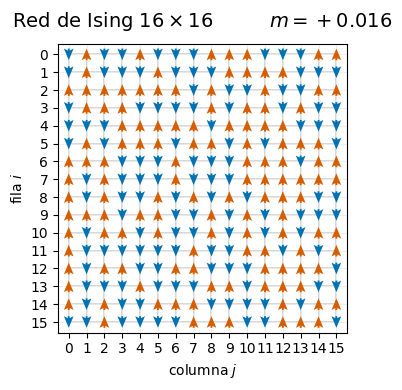

<Axes: title={'center': 'Red de Ising $16\\times16$   $\\qquad m=+0.016$'}, xlabel='columna $j$', ylabel='fila $i$'>

In [270]:
graficar_configuracion(
    red,
    espines,
    tam_flecha=0.65,
    ancho_flecha=0.025,
    tam_cabeza=5
)

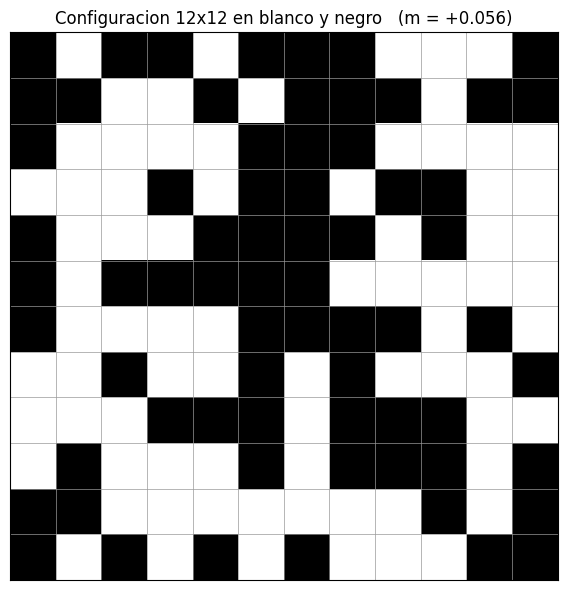

<Axes: title={'center': 'Configuracion 12x12 en blanco y negro   (m = +0.056)'}>

In [229]:
graficar_configuracion_bn(red, espines)

La vista en blanco y negro se vuelve más informativa a medida que crece $L$. En una red grande, una configuración aleatoria (temperatura infinita) se ve como ruido sin estructura espacial:

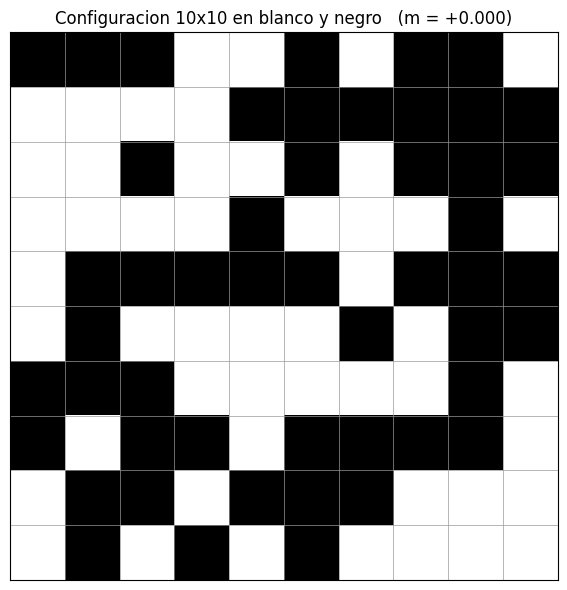

<Axes: title={'center': 'Configuracion 10x10 en blanco y negro   (m = +0.000)'}>

In [266]:
red_grande = RedIsing2D(L=10, frontera='periodica')
espines_grande = asignar_espines_aleatorios(red_grande, semilla=7)
graficar_configuracion_bn(red_grande, espines_grande)

## 3. Dinámica de Monte Carlo (algoritmo de Metropolis)

Con una configuración de espines definida, queremos muestrear el **equilibrio térmico** a temperatura $T$. En unidades normalizadas ($J = 1$, $k_B = 1$) el Hamiltoniano es

$$H(\{s\}) = -J\sum_{\langle i,j\rangle} s_i s_j,$$

donde la suma recorre cada par de primeros vecinos una sola vez. En equilibrio, la probabilidad de una configuración es la de Boltzmann, $P(\{s\}) \propto e^{-H/T}$.

### Paso de Metropolis

Repetir muchas veces:

1. Elegir un sitio $i$.
2. Calcular el cambio de energía al voltear ese espín, $s_i \to -s_i$:
   $$\Delta E = 2\,J\,s_i \sum_{j\,\in\,\text{vec}(i)} s_j.$$
3. Aceptar el volteo con probabilidad $p_{\text{acc}} = \min\!\left(1,\; e^{-\Delta E / T}\right)$: si $\Delta E \le 0$ se acepta siempre; si $\Delta E > 0$, con probabilidad $e^{-\Delta E/T}$.

Un **barrido** (*sweep*) equivale a $N = L^2$ intentos de volteo; es la unidad natural de "tiempo" de Monte Carlo.

### Actualización por tablero de ajedrez (vectorizada)

En la red cuadrada, los vecinos de un sitio "blanco" son todos "negros" y viceversa (red bipartita). Por eso se pueden voltear **todos** los sitios de un color a la vez sin que interfieran: cada barrido actualiza primero una subred y luego la otra. Esto permite implementar Metropolis con operaciones de NumPy sobre toda la matriz, mucho más rápido que un bucle sitio a sitio. Con frontera periódica conviene $L$ par, para que el tablero cierre bien sobre el toro.

### Recorrido de alta a baja temperatura (recocido)

Para las curvas de observables recorreremos las temperaturas **de mayor a menor**:

- se parte de $T$ alta con una configuración aleatoria (*arranque caliente*, equilibra muy rápido);
- para cada $T$ siguiente (más baja) se reutiliza la configuración final de la $T$ anterior.

Así el sistema siempre está cerca del equilibrio (menos termalización) y, al enfriar, la simetría $\pm$ se rompe una sola vez: la magnetización sigue de forma continua una de las dos ramas, lo que da curvas limpias de $|m|(T)$.


In [231]:
TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))   # ~2.269185, temperatura critica de Onsager (en J/k_B)


class IsingMetropolis:
    """Dinamica de Metropolis (vectorizada por tablero de ajedrez) para el Ising 2D.

    Unidades normalizadas: por defecto J = 1 y k_B = 1, de modo que la temperatura T
    se mide en unidades de J/k_B.  Hamiltoniano:  H = -J * sum_<ij> s_i s_j.

    Parametros
    ----------
    L : int
        Tamano lineal de la red. Con frontera periodica conviene L par.
    T : float
        Temperatura (en J/k_B). Se puede cambiar despues con `mc.T = nuevo_valor`.
    frontera : str
        'periodica' (toro, la de Onsager) o 'libre' (bordes abiertos).
    espines : np.ndarray (L, L) o (L*L,), opcional
        Configuracion inicial de +-1. Si es None se genera aleatoria (arranque caliente).
    J : float
        Constante de acoplamiento.
    semilla : int o None
        Semilla del generador aleatorio.
    """

    def __init__(self, L, T, frontera='periodica', espines=None, J=1.0, semilla=None):
        if frontera not in ('periodica', 'libre'):
            raise ValueError("frontera debe ser 'periodica' o 'libre'")
        self.L = int(L)
        self.N = self.L * self.L
        self.frontera = frontera
        self.J = float(J)
        self.rng = np.random.default_rng(semilla)
        self.T = T                       # activa el setter: fija self._T y self.beta

        if frontera == 'periodica' and self.L % 2 != 0:
            import warnings
            warnings.warn("Con frontera periodica conviene L par para que el tablero de "
                          "ajedrez cierre bien sobre el toro (con L impar hay un leve sesgo).")

        if espines is None:
            self.s = self.rng.choice(np.array([-1, 1], dtype=np.int8), size=(self.L, self.L))
        else:
            self.s = np.asarray(espines, dtype=np.int8).reshape(self.L, self.L).copy()

        i, j = np.indices((self.L, self.L))
        self.sub_A = ((i + j) % 2 == 0)   # subred "blanca" del tablero
        self.sub_B = ~self.sub_A          # subred "negra"

    @property
    def T(self):
        return self._T

    @T.setter
    def T(self, valor):
        self._T = float(valor)
        self.beta = 1.0 / self._T

    def _suma_vecinos(self):
        """Suma de los espines de los primeros vecinos de cada sitio -> matriz (L, L)."""
        s = self.s
        if self.frontera == 'periodica':
            return (np.roll(s, 1, 0) + np.roll(s, -1, 0)
                    + np.roll(s, 1, 1) + np.roll(s, -1, 1))
        arriba = np.zeros_like(s); arriba[1:, :] = s[:-1, :]
        abajo = np.zeros_like(s);  abajo[:-1, :] = s[1:, :]
        izq = np.zeros_like(s);    izq[:, 1:] = s[:, :-1]
        der = np.zeros_like(s);    der[:, :-1] = s[:, 1:]
        return arriba + abajo + izq + der

    def barrido(self):
        """Un barrido de Metropolis: actualiza la subred A y despues la B."""
        for subred in (self.sub_A, self.sub_B):
            vecinos = self._suma_vecinos()
            dE = 2.0 * self.J * self.s * vecinos                  # cambio de energia al voltear s_i
            prob = np.exp(-self.beta * np.clip(dE, 0.0, None))    # =1 si dE<=0; evita overflow en exp
            voltea = (self.rng.random(self.s.shape) < prob) & subred
            self.s[voltea] = -self.s[voltea]

    def termalizar(self, n_barridos):
        """Ejecuta n_barridos sin medir (aproximacion al equilibrio)."""
        for _ in range(int(n_barridos)):
            self.barrido()

    def energia(self):
        """Energia total  E = -J sum_<ij> s_i s_j  (cada enlace contado una vez)."""
        s = self.s.astype(np.int64)
        if self.frontera == 'periodica':
            pares = s * (np.roll(s, -1, 0) + np.roll(s, -1, 1))
            return -self.J * float(pares.sum())
        pares = (s[:-1, :] * s[1:, :]).sum() + (s[:, :-1] * s[:, 1:]).sum()
        return -self.J * float(pares)

    def magnetizacion(self):
        """Magnetizacion total  M = sum_i s_i."""
        return int(self.s.sum(dtype=np.int64))

    def configuracion(self):
        """Copia de la configuracion actual como matriz (L, L) de +-1 (int8)."""
        return self.s.copy()


## 4. Observables: energía, magnetización, calor específico y susceptibilidad

Todas las cantidades se dan **por sitio** ($N = L^2$) para comparar redes de distinto tamaño. Los promedios $\langle\cdot\rangle$ son sobre configuraciones de equilibrio a una misma $T$.

| Observable | Definición | Comportamiento |
|---|---|---|
| Energía por sitio | $\displaystyle u = \frac{\langle H\rangle}{N}$ | $u \to -2J$ cuando $T\to 0$ (enlaces satisfechos, frontera periódica); $u \to 0$ cuando $T\to\infty$. |
| Magnetización por sitio | $\displaystyle m = \frac{\langle \lvert M\rvert\rangle}{N},\quad M=\sum_i s_i$ | Se usa $\lvert M\rvert$: en red finita el sistema alterna entre las ramas $+$ y $-$ y $\langle M\rangle\to 0$ por simetría. $m\to 1$ a baja $T$, $m\to 0$ a alta $T$. |
| Calor específico por sitio | $\displaystyle c_V = \frac{\langle H^2\rangle - \langle H\rangle^2}{N\,T^2}$ | Relación fluctuación–disipación ($k_B=1$). Pico cerca de $T_c$ (divergencia logarítmica en el límite termodinámico). |
| Susceptibilidad magnética por sitio | $\displaystyle \chi = \frac{\langle M^2\rangle - \langle \lvert M\rvert\rangle^2}{N\,T}$ | Respuesta de la magnetización. Pico pronunciado cerca de $T_c$. |

En unidades normalizadas la transición ocurre en la **temperatura crítica de Onsager**

$$T_c = \frac{2}{\ln\!\left(1+\sqrt{2}\right)} \approx 2.269\ \ (J/k_B).$$

`medir_observables` termaliza y promedia sobre barridos (submuestreando para reducir la autocorrelación); `barrido_annealing` la aplica a una lista de temperaturas recorrida de **alta a baja**.


In [232]:
import pandas as pd


def medir_observables(mc, n_termalizacion=2000, n_medidas=3000, submuestreo=5,
                      guardar_configs=False):
    """Termaliza el simulador `mc` a su temperatura actual y estima los observables por sitio.

    Parametros
    ----------
    mc : IsingMetropolis
        Simulador ya construido; se parte de su configuracion actual.
    n_termalizacion : int
        Barridos descartados antes de medir.
    n_medidas : int
        Barridos de medicion.
    submuestreo : int
        Se registra una medida cada `submuestreo` barridos (reduce la autocorrelacion).
    guardar_configs : bool
        Si True, tambien devuelve la lista de configuraciones muestreadas.

    Devuelve
    --------
    obs : dict con T, u, m, cv, chi (por sitio) y errores simples.
    configs : list[np.ndarray]   (solo si guardar_configs=True)
    """
    N, T = mc.N, mc.T
    mc.termalizar(n_termalizacion)

    E, M_abs, M2 = [], [], []
    configs = []
    for t in range(int(n_medidas)):
        mc.barrido()
        if t % submuestreo == 0:
            e_tot = mc.energia()
            m_tot = mc.magnetizacion()
            E.append(e_tot)
            M_abs.append(abs(m_tot))
            M2.append(m_tot * m_tot)
            if guardar_configs:
                configs.append(mc.configuracion())

    E = np.asarray(E, dtype=float)
    M_abs = np.asarray(M_abs, dtype=float)
    M2 = np.asarray(M2, dtype=float)

    obs = {
        'T': T,
        'u': E.mean() / N,                                   # energia por sitio
        'm': M_abs.mean() / N,                               # |magnetizacion| por sitio
        'cv': E.var() / (N * T * T),                         # (<E^2> - <E>^2) / (N T^2)
        'chi': (M2.mean() - M_abs.mean() ** 2) / (N * T),    # (<M^2> - <|M|>^2) / (N T)
        'u_err': E.std(ddof=1) / np.sqrt(len(E)) / N,
        'm_err': M_abs.std(ddof=1) / np.sqrt(len(M_abs)) / N,
        'n_muestras': len(E),
    }
    return (obs, configs) if guardar_configs else obs


def barrido_annealing(L, temperaturas, frontera='periodica', J=1.0,
                      n_termalizacion=1500, n_medidas=3000, submuestreo=5,
                      semilla=0, verbose=True):
    """Recorre `temperaturas` de MAYOR a MENOR (recocido) midiendo observables por sitio.

    La configuracion final de cada temperatura sirve de arranque para la siguiente
    (mas baja): arranque caliente global y ruptura de simetria unica, lo que da
    curvas limpias de |m|(T).

    Devuelve
    --------
    df : pandas.DataFrame  con columnas T, u, m, cv, chi, ...  ordenado de T alta a baja.
    """
    temperaturas = np.sort(np.asarray(temperaturas, dtype=float))[::-1]   # alta -> baja
    mc = IsingMetropolis(L, T=temperaturas[0], frontera=frontera, J=J, semilla=semilla)

    filas = []
    for k, T in enumerate(temperaturas):
        mc.T = T                              # reutiliza la configuracion actual
        obs = medir_observables(mc, n_termalizacion, n_medidas, submuestreo)
        filas.append(obs)
        if verbose:
            print(f"[{k + 1:2d}/{len(temperaturas)}]  T = {T:5.3f}   "
                  f"u = {obs['u']:+.3f}   m = {obs['m']:.3f}   "
                  f"cv = {obs['cv']:.3f}   chi = {obs['chi']:8.3f}")

    return pd.DataFrame(filas)


### Promedio configuracional: varias realizaciones

Un solo recorrido de recocido es **una realización**: una trayectoria concreta de la cadena de Markov, con su propia semilla y su propio arranque aleatorio. Los observables que salen de ahí todavía fluctúan de una realización a otra (sobre todo cerca de $T_c$, donde las fluctuaciones críticas y el *critical slowing down* son grandes). Una curva aislada **no** es "la solución": es una muestra.

La estimación estadística correcta es promediar sobre **$R$ cadenas independientes**:

$$\overline{A}(T) = \frac{1}{R}\sum_{r=1}^{R} A^{(r)}(T), \qquad
\text{error}(T) = \frac{\sigma_R\big(A(T)\big)}{\sqrt{R}},$$

donde $A^{(r)}(T)$ es ya un promedio térmico dentro de la realización $r$ (sobre barridos, como en §4) y $\sigma_R$ es la desviación estándar entre realizaciones. `curvas_promedio` hace exactamente esto: lanza $R$ recocidos independientes (semillas hijas de una misma `SeedSequence`) y devuelve `resumen` (media y error por temperatura) y `crudo` (todas las realizaciones, para dibujarlas de fondo).

> Una sola realización sigue disponible con `barrido_annealing(L, temperaturas, semilla=0)`.


In [233]:
def curvas_promedio(L, temperaturas, n_realizaciones=6, frontera='periodica', J=1.0,
                    n_termalizacion=1200, n_medidas=2500, submuestreo=5, semilla=0,
                    verbose=True):
    """Promedio configuracional: repite el recocido `n_realizaciones` veces (cadenas
    de Monte Carlo independientes) y promedia los observables por temperatura.

    Cada realizacion recorre `temperaturas` de alta a baja (ver `barrido_annealing`).
    Las semillas de las realizaciones son hijas de una misma SeedSequence: son
    independientes y el resultado es reproducible a partir de `semilla`.

    Devuelve
    --------
    resumen : DataFrame  (una fila por temperatura, de T alta a baja)
        Columnas: T, u, u_err, m, m_err, cv, cv_err, chi, chi_err, n_realizaciones.
        *_err es el error estandar de la media entre realizaciones (sigma/sqrt(R)).
    crudo : DataFrame
        Todas las realizaciones apiladas, con la columna 'realizacion' (0..R-1).
    """
    semillas_hijas = np.random.SeedSequence(semilla).spawn(n_realizaciones)

    dfs = []
    for r, sem in enumerate(semillas_hijas):
        df_r = barrido_annealing(L, temperaturas, frontera=frontera, J=J,
                                 n_termalizacion=n_termalizacion, n_medidas=n_medidas,
                                 submuestreo=submuestreo, semilla=sem, verbose=False)
        df_r['realizacion'] = r
        dfs.append(df_r)
        if verbose:
            print(f"realizacion {r + 1}/{n_realizaciones} lista")

    crudo = pd.concat(dfs, ignore_index=True)

    g = crudo.groupby('T', sort=False)
    resumen = pd.DataFrame({
        'T':   list(g.groups.keys()),
        'u':   g['u'].mean().values,     'u_err':   g['u'].sem().values,
        'm':   g['m'].mean().values,     'm_err':   g['m'].sem().values,
        'cv':  g['cv'].mean().values,    'cv_err':  g['cv'].sem().values,
        'chi': g['chi'].mean().values,   'chi_err': g['chi'].sem().values,
        'n_realizaciones': g.size().values,
    }).sort_values('T', ascending=False).reset_index(drop=True)

    return resumen, crudo


In [234]:
# Promedio configuracional: R cadenas de Monte Carlo independientes, cada una
# recorriendo las temperaturas de ALTA a BAJA (recocido).  Puede tardar ~30-70 s.
L = 24
temperaturas = np.concatenate([
    np.linspace(3.60, 2.60,  6),    # T > T_c : fase desordenada
    np.linspace(2.50, 2.05, 12),    # entorno de T_c (rejilla mas fina)
    np.linspace(1.95, 1.00, 10),    # T < T_c : fase ordenada
])

resumen, crudo = curvas_promedio(
    L, temperaturas, n_realizaciones=6, frontera='periodica',
    n_termalizacion=1200, n_medidas=2500, submuestreo=5, semilla=0,
)
resumen.round(4)


realizacion 1/6 lista
realizacion 2/6 lista
realizacion 3/6 lista
realizacion 4/6 lista
realizacion 5/6 lista
realizacion 6/6 lista


,T,u,u_err,m,m_err,cv,cv_err,chi,chi_err,n_realizaciones
0,3.6000,-0.6347,0.0020,0.0791,0.0011,0.2237,0.0040,0.5458,0.0183,6
1,3.4000,-0.6851,0.0015,0.0870,0.0013,0.2685,0.0050,0.7265,0.0223,6
2,3.2000,-0.7447,0.0011,0.0957,0.0012,0.3207,0.0094,0.9344,0.0134,6
3,3.0000,-0.8157,0.0011,0.1151,0.0009,0.3922,0.0157,1.3388,0.0284,6
4,2.8000,-0.9080,0.0007,0.1414,0.0023,0.5238,0.0194,2.0911,0.0333,6
5,2.6000,-1.0277,0.0013,0.2035,0.0042,0.7428,0.0150,4.5971,0.1070,6
6,2.5000,-1.1109,0.0023,0.2717,0.0056,0.9362,0.0193,7.0443,0.1046,6
7,2.4591,-1.1588,0.0036,0.3195,0.0104,1.0978,0.0278,9.5104,0.3132,6
8,2.4182,-1.2046,0.0023,0.3852,0.0029,1.3392,0.0341,11.2627,0.2698,6
9,2.3773,-1.2624,0.0027,0.4549,0.0073,1.5435,0.0264,11.9489,0.1498,6


### Curvas promedio y $c_V$ frente a la magnetización

Las gráficas siguientes muestran, para cada observable, **las realizaciones individuales** (líneas tenues: una por cadena) y **el promedio configuracional** con barras de error (media $\pm$ error estándar entre realizaciones). Se ve que:

- lejos de $T_c$ las realizaciones casi coinciden (poca dispersión);
- cerca de $T_c$ la dispersión entre realizaciones crece: ahí es donde el promedio sobre cadenas y las barras de error importan.

Comportamiento esperado al enfriar de $T$ alta a baja: $u:\ 0 \to -2J$; $|m|:\ 0 \to 1$ de forma abrupta cerca de $T_c$; $c_V$ y $\chi$ con un **pico cerca de $T_c$** (redondeado y algo desplazado por el tamaño finito).

En la curva **$c_V$ vs. $|m|$** cada punto es una temperatura (color) del promedio configuracional: el sistema parte de $|m|\approx0$ ($T$ alta), sube al máximo de $c_V$ al cruzar $T_c$ (a $|m|$ intermedio) y baja hacia $c_V\to0$ cuando $|m|\to1$ ($T$ baja).


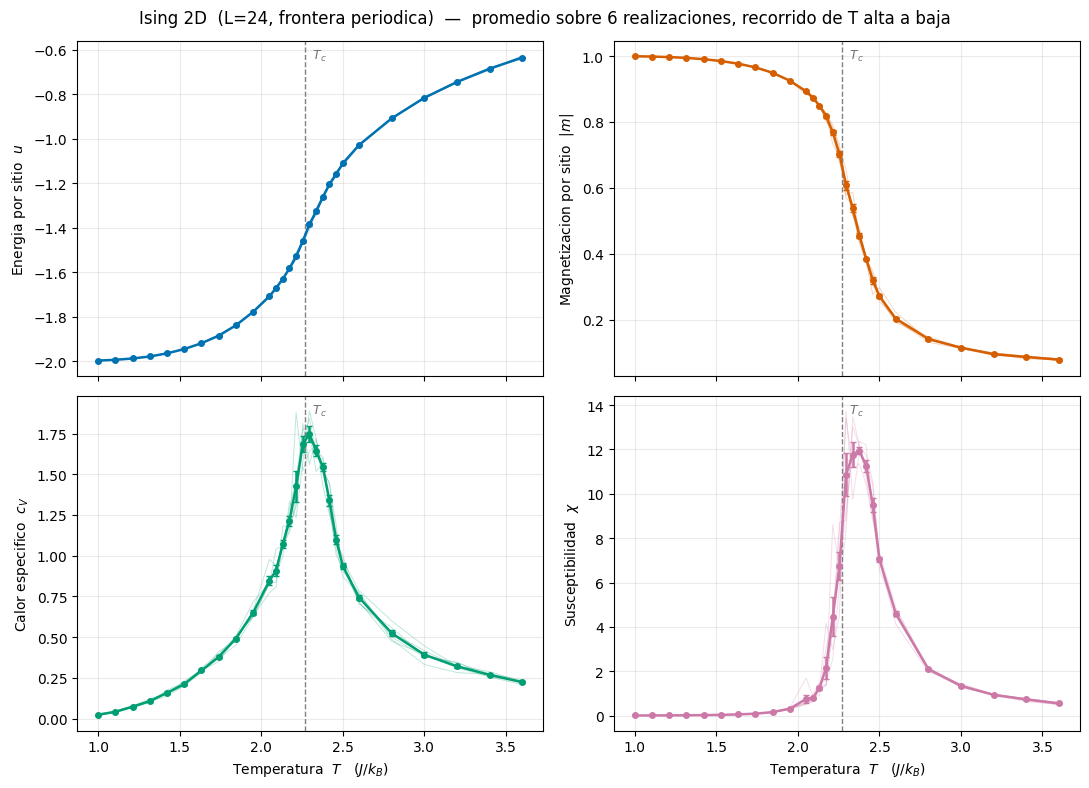

In [235]:
# Observables por sitio frente a T: realizaciones (tenues) + promedio configuracional (con error).
Tc = TC_ONSAGER
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

paneles = [
    ('u',   r'Energia por sitio  $u$'),
    ('m',   r'Magnetizacion por sitio  $|m|$'),
    ('cv',  r'Calor especifico  $c_V$'),
    ('chi', r'Susceptibilidad  $\chi$'),
]
colores = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']

for ax, (col, etiqueta), color in zip(axes.flat, paneles, colores):
    for _, sub in crudo.groupby('realizacion'):
        sub = sub.sort_values('T', ascending=False)
        ax.plot(sub['T'], sub[col], '-', color=color, lw=0.7, alpha=0.25, zorder=1)
    ax.errorbar(resumen['T'], resumen[col], yerr=resumen[col + '_err'],
                fmt='o-', color=color, lw=1.8, ms=4, capsize=2, zorder=3)
    ax.axvline(Tc, color='0.5', ls='--', lw=1)
    ax.text(Tc, 0.98, r'  $T_c$', transform=ax.get_xaxis_transform(),
            va='top', ha='left', color='0.45', fontsize=9)
    ax.set_ylabel(etiqueta)
    ax.grid(alpha=0.25)

for ax in axes[1, :]:
    ax.set_xlabel(r'Temperatura  $T$   ($J/k_B$)')

R = int(resumen['n_realizaciones'].iloc[0])
fig.suptitle(f'Ising 2D  (L={L}, frontera periodica)  —  promedio sobre {R} realizaciones, '
             f'recorrido de T alta a baja')
fig.tight_layout()
plt.show()


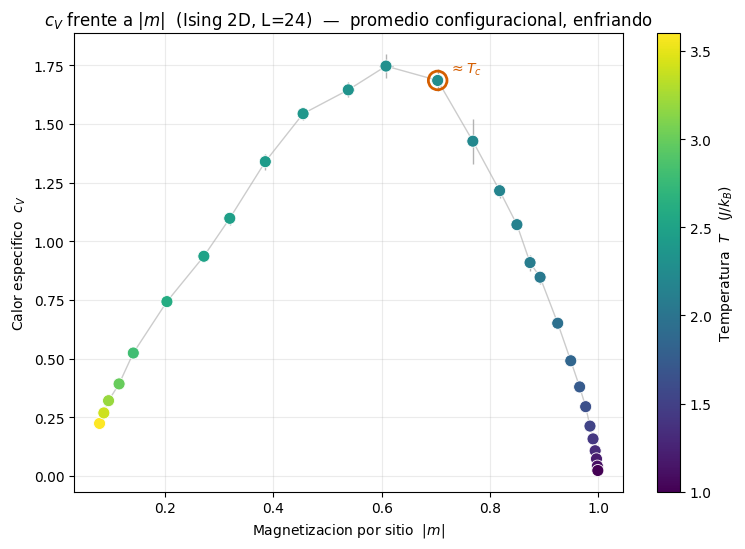

In [236]:
# c_V frente a |m| (promedio configuracional), con la temperatura codificada en color.
mvals = resumen['m'].to_numpy()
cvvals = resumen['cv'].to_numpy()
m_err = resumen['m_err'].to_numpy()
cv_err = resumen['cv_err'].to_numpy()
Tvals = resumen['T'].to_numpy()

fig, ax = plt.subplots(figsize=(7.8, 5.6))
ax.errorbar(mvals, cvvals, xerr=m_err, yerr=cv_err, fmt='none',
            ecolor='0.7', elinewidth=1, zorder=1)
ax.plot(mvals, cvvals, '-', color='0.8', lw=1, zorder=1)
sc = ax.scatter(mvals, cvvals, c=Tvals, cmap='viridis', s=75,
                zorder=2, edgecolors='white', linewidths=0.6)
cb = fig.colorbar(sc, ax=ax)
cb.set_label(r'Temperatura  $T$   ($J/k_B$)')

k_c = int(np.argmin(np.abs(Tvals - TC_ONSAGER)))
ax.scatter([mvals[k_c]], [cvvals[k_c]], s=180, facecolors='none',
           edgecolors='#D55E00', linewidths=2, zorder=3)
ax.annotate(r'$\approx T_c$', (mvals[k_c], cvvals[k_c]),
            textcoords='offset points', xytext=(8, 6), color='#D55E00')

ax.set_xlabel(r'Magnetizacion por sitio  $|m|$')
ax.set_ylabel(r'Calor especifico  $c_V$')
ax.set_title(f'$c_V$ frente a $|m|$  (Ising 2D, L={L})  —  promedio configuracional, enfriando')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 5. Construcción del dataset: configuraciones etiquetadas por fase

### 5.1 Qué guarda el dataset (y en qué se diferencia de §4)

Las curvas de §4 promedian **observables escalares** (un número por temperatura). Para entrenar la red hace falta lo contrario: las **configuraciones completas** $\{s_i\}$, matrices $L\times L$ de $\pm1$, porque la red aprende a distinguir la fase mirando el **patrón espacial** de espines, no un promedio.

| | fase **desordenada** (`y = 1`) | fase **ordenada** (`y = 0`) |
|---|---|---|
| temperatura | $T > T_c$ | $T < T_c$ |
| aspecto | "ruido", sin dominios | un dominio grande domina la red |
| $\lvert m\rvert$ por configuración | $\approx 0$ | cercano a 1 |

### 5.2 Cuántas configuraciones se almacenan por temperatura

Para cada temperatura $T$ de la lista (recorrida de alta a baja), y en **cada** realización independiente:

1. se termaliza `n_termalizacion` barridos (llegar al equilibrio a esa $T$);
2. se toman `n_config_por_T` **instantáneas**, separadas por `barridos_entre_config` barridos de Monte Carlo → muestras **decorrelacionadas** de la misma distribución de Boltzmann $P(\{s\})\propto e^{-H/T}$;
3. las temperaturas con $\lvert T - T_c\rvert < \texttt{margen}$ se **saltan** (etiqueta ambigua) y no aportan configuraciones.

Número total de configuraciones almacenadas:

$$N \;=\; \underbrace{n_\text{realizaciones}}_{\text{cadenas independientes}}\;\times\;\underbrace{n_T^{\text{válidas}}}_{\text{temperaturas fuera de la banda}}\;\times\;\underbrace{\texttt{n\_config\_por\_T}}_{\text{por temperatura}}$$

**Ejemplo concreto.** Con `n_realizaciones = 4`, `n_config_por_T = 60` y $T = 3.0$ (fuera de la banda, $T > T_c$): se guardan $4 \times 60 = 240$ configuraciones **distintas**, todas con `T = 3.0` y `y = 1` (desordenada). A $T = 1.5$: otras 240, todas `y = 0` (ordenada). Y así en cada temperatura de la lista. Todas esas configuraciones —no un resumen— son las que ve la red: cada una es **un ejemplo de entrenamiento** (una imagen con su etiqueta).

### 5.3 Simetría $s \to -s$ (por qué `simetrizar=True`)

El Hamiltoniano no cambia si se invierten **todos** los espines a la vez. En la fase ordenada, cada cadena de Monte Carlo se "congela" en **uno** de los dos sentidos (todo $+$ o todo $-$) según el azar de esa realización. Sin corregirlo, la clase ordenada quedaría sesgada hacia un signo y la red podría aprender un atajo tramposo ("hay más $+1$ ⇒ ordenada") en lugar de la estructura de dominios.

`simetrizar=True` invierte el signo global de cada configuración con probabilidad $1/2$ **al guardarla**: no cambia la fase ni $\lvert m\rvert$, pero equilibra la clase ordenada entre $m>0$ y $m<0$. Usar varias realizaciones ayuda por la misma razón.

### 5.4 Estructura del archivo `ising_dataset.npz`

`np.savez_compressed` guarda un diccionario de arrays alineados fila a fila:

| clave | forma | dtype | significado |
|---|---|---|---|
| `X` | `(N, L, L)` | `int8` | las `N` configuraciones de espines $\pm1$ — **entrada de la red** |
| `y` | `(N,)` | `int8` | fase: **0 = ordenada** ($T<T_c$), **1 = desordenada** ($T>T_c$) — **objetivo** |
| `T` | `(N,)` | `float64` | temperatura con la que se generó cada configuración (metadato) |
| `m` | `(N,)` | `float64` | $\lvert m\rvert$ por sitio de cada configuración (metadato de diagnóstico) |
| `realizacion` | `(N,)` | `int16` | índice de la cadena de Monte Carlo que la generó (metadato) |
| `Tc` | escalar | `float64` | $T_c$ de Onsager usado para etiquetar |
| `L` | escalar | `int64` | tamaño lineal de la red |
| `frontera` | escalar | `str` | condición de frontera (`'periodica'`) |

`X[k]`, `y[k]`, `T[k]`, `m[k]`, `realizacion[k]` describen **la misma** configuración. Las filas salen ordenadas por realización y luego por temperatura (de alta a baja): **hay que barajar** antes de partir en train/test.

Solo `X` e `y` entran al entrenamiento; `T`, `m` y `realizacion` sirven para analizar después (p. ej. medir el acierto de la red en función de $T$, o ver si falla más cerca de $T_c$).

### 5.5 Cómo leerlo para la red neuronal

La celda de lectura hace: cargar el `.npz`, pasar `X` a `float32`, **barajar**, elegir la forma según el tipo de red (vector $L^2$ para un MLP, tensor $(L, L, 1)$ para una CNN) y partir en train/test manteniendo el balance de clases.


In [237]:
def generar_dataset_ising(L, temperaturas, n_config_por_T, n_realizaciones=1,
                          frontera='periodica', J=1.0, n_termalizacion=2000,
                          barridos_entre_config=25, margen=0.15, simetrizar=True,
                          semilla=0, verbose=True):
    """Genera configuraciones de Ising etiquetadas por fase (recocido de T alta a baja).

    Para cada realizacion (cadena de Monte Carlo independiente) se recorre `temperaturas`
    de mayor a menor; en cada T se termaliza y luego se guardan `n_config_por_T`
    instantaneas separadas por `barridos_entre_config` barridos (poco correlacionadas).
    Las temperaturas con |T - T_c| < margen se saltan (etiqueta ambigua).

    Total de configuraciones:  n_realizaciones * (nº de T validas) * n_config_por_T.

    Parametros
    ----------
    n_realizaciones : int
        Cadenas independientes (semillas hijas de `semilla`). Mas realizaciones ->
        mas variedad configuracional en el dataset.
    simetrizar : bool
        Si True, cada configuracion se guarda con el signo global invertido con
        probabilidad 1/2. El Ising es invariante bajo s -> -s: esto equilibra la
        fase ordenada entre m>0 y m<0 y evita que la red aprenda el signo.
    margen : float
        Semiancho de la banda alrededor de T_c que se excluye.

    Devuelve
    --------
    X : np.ndarray (N, L, L) int8     configuraciones de +-1
    T : np.ndarray (N,) float         temperatura de cada configuracion
    y : np.ndarray (N,) int8          0 = ordenada (T < T_c), 1 = desordenada (T > T_c)
    m : np.ndarray (N,) float         |magnetizacion| por sitio de cada configuracion
    realizacion : np.ndarray (N,) int16   indice de la cadena que la genero
    """
    temperaturas = np.sort(np.asarray(temperaturas, dtype=float))[::-1]   # alta -> baja
    Tc = 2.0 / np.log(1.0 + np.sqrt(2.0))

    ss = np.random.SeedSequence(semilla)
    sim_rng = np.random.default_rng(ss.spawn(1)[0])          # solo para la simetrizacion
    semillas_cadenas = ss.spawn(n_realizaciones)

    X, T_lista, y_lista, m_lista, r_lista = [], [], [], [], []
    for r, sem in enumerate(semillas_cadenas):
        mc = IsingMetropolis(L, T=temperaturas[0], frontera=frontera, J=J, semilla=sem)
        for Temp in temperaturas:
            mc.T = Temp
            mc.termalizar(n_termalizacion)
            if abs(Temp - Tc) < margen:
                continue                                     # banda critica: no se guarda
            for _ in range(int(n_config_por_T)):
                mc.termalizar(barridos_entre_config)
                conf = mc.configuracion()
                if simetrizar and sim_rng.random() < 0.5:
                    conf = (-conf).astype(np.int8)
                X.append(conf)
                T_lista.append(Temp)
                y_lista.append(0 if Temp < Tc else 1)
                m_lista.append(abs(int(conf.sum(dtype=np.int64))) / mc.N)
                r_lista.append(r)
        if verbose:
            n_T_validas = int((np.abs(temperaturas - Tc) >= margen).sum())
            print(f"realizacion {r + 1}/{n_realizaciones}: "
                  f"{n_T_validas} temperaturas x {n_config_por_T} configs")

    return (np.asarray(X, dtype=np.int8),
            np.asarray(T_lista, dtype=float),
            np.asarray(y_lista, dtype=np.int8),
            np.asarray(m_lista, dtype=float),
            np.asarray(r_lista, dtype=np.int16))


In [238]:
# Dataset de demostracion. Sube n_realizaciones / n_config_por_T / L para el dataset real.
temps_dataset = np.concatenate([
    np.linspace(3.50, 2.60, 5),    # T > T_c  -> fase desordenada  (y = 1)
    np.linspace(1.90, 1.20, 5),    # T < T_c  -> fase ordenada     (y = 0)
])

X, T_muestra, y, m_muestra, realizacion = generar_dataset_ising(
    L=16, temperaturas=temps_dataset, n_config_por_T=40, n_realizaciones=4,
    frontera='periodica', n_termalizacion=1500, barridos_entre_config=20,
    margen=0.0, simetrizar=True, semilla=1,
)

R = len(np.unique(realizacion))
n_T = len(np.unique(T_muestra))
print(f"\n{R} realizaciones x {n_T} temperaturas x 40 configs  =  {len(y)} configuraciones")
print(f"X: {X.shape}  dtype={X.dtype}   ({X.nbytes / 1024:.0f} KiB en memoria)")
print(f"y == 1 (desordenada, T > T_c): {(y == 1).sum()}     y == 0 (ordenada, T < T_c): {(y == 0).sum()}")
print(f"|m| medio  ->  desordenada: {m_muestra[y == 1].mean():.3f}     ordenada: {m_muestra[y == 0].mean():.3f}")

# Con simetrizar=True, la fase ordenada deberia quedar ~50/50 entre m>0 y m<0
signo_ord = np.array([np.sign(X[k].sum()) for k in np.where(y == 0)[0]])
print(f"fase ordenada:  {(signo_ord > 0).sum()} con m>0  /  {(signo_ord < 0).sum()} con m<0")

ruta = 'ising_dataset.npz'
np.savez_compressed(
    ruta, X=X, y=y, T=T_muestra, m=m_muestra, realizacion=realizacion,
    Tc=TC_ONSAGER, L=np.int64(16), frontera='periodica',
)
print(f"\nguardado en: {ruta}")


realizacion 1/4: 10 temperaturas x 40 configs
realizacion 2/4: 10 temperaturas x 40 configs
realizacion 3/4: 10 temperaturas x 40 configs
realizacion 4/4: 10 temperaturas x 40 configs

4 realizaciones x 10 temperaturas x 40 configs  =  1600 configuraciones
X: (1600, 16, 16)  dtype=int8   (400 KiB en memoria)
y == 1 (desordenada, T > T_c): 800     y == 0 (ordenada, T < T_c): 800
|m| medio  ->  desordenada: 0.191     ordenada: 0.975
fase ordenada:  414 con m>0  /  386 con m<0

guardado en: ising_dataset.npz


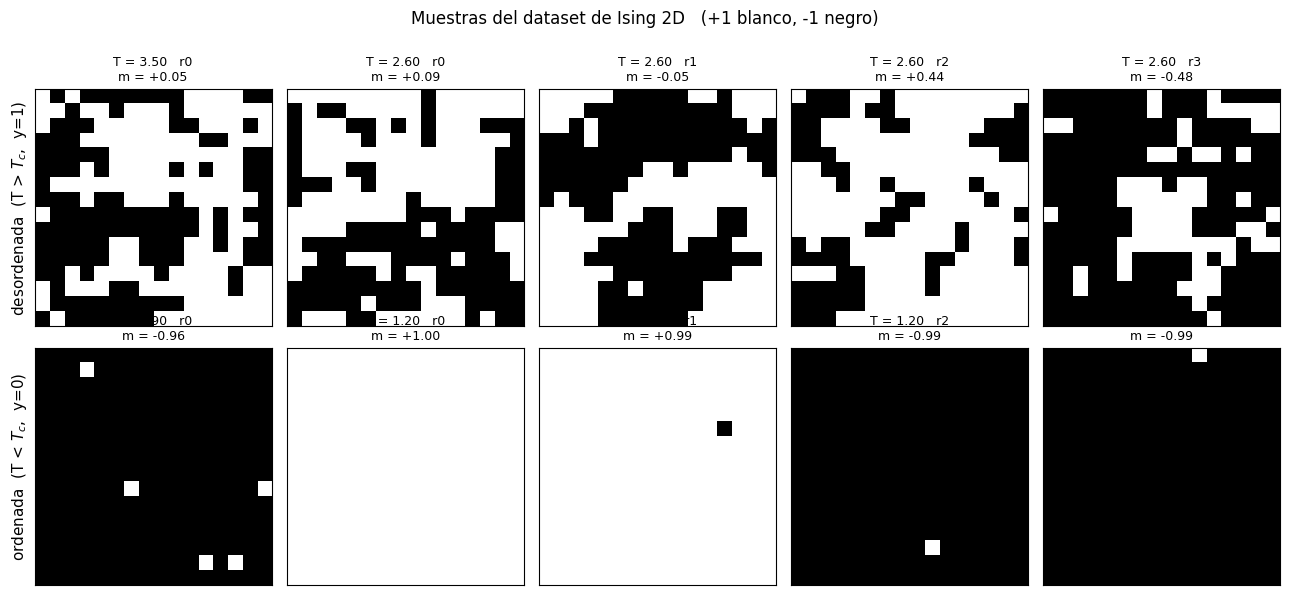

In [239]:
# Muestras del dataset: 5 configuraciones de cada fase (tomadas de distintas realizaciones/T)
fig, axes = plt.subplots(2, 5, figsize=(13, 5.8))

for fila, (fase, titulo) in enumerate([(1, 'desordenada  (T > $T_c$,  y=1)'),
                                       (0, 'ordenada  (T < $T_c$,  y=0)')]):
    idx = np.where(y == fase)[0]
    sel = idx[np.linspace(0, len(idx) - 1, 5).astype(int)]
    for ax, k in zip(axes[fila], sel):
        ax.imshow(X[k], cmap='gray', vmin=-1, vmax=1, interpolation='nearest')
        ax.set_title(f'T = {T_muestra[k]:.2f}   r{realizacion[k]}\n'
                     f'm = {np.mean(X[k]):+.2f}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    axes[fila, 0].set_ylabel(titulo, fontsize=11)

fig.suptitle('Muestras del dataset de Ising 2D   (+1 blanco, -1 negro)', y=1.02)
fig.tight_layout()
plt.show()


In [240]:
# --- Lectura de ising_dataset.npz para la red neuronal ---------------------------
datos = np.load('ising_dataset.npz', allow_pickle=False)
print("claves:", list(datos.keys()))

Xd = datos['X'].astype(np.float32)     # (N, L, L)   espines -1.0 / +1.0  -> entrada
yd = datos['y'].astype(np.int64)       # (N,)        0 = ordenada, 1 = desordenada -> objetivo
Td = datos['T']                        # (N,)        metadatos para el analisis posterior
md = datos['m']
rd = datos['realizacion']
Ld = int(datos['L'])
Tcd = float(datos['Tc'])
N = len(yd)
print(f"N = {N} configuraciones de {Ld}x{Ld}   |   "
      f"y=0 (ordenada): {(yd == 0).sum()}   y=1 (desordenada): {(yd == 1).sum()}")

# 1) BARAJAR: las filas vienen ordenadas por realizacion y temperatura
rng = np.random.default_rng(0)
perm = rng.permutation(N)
Xd, yd, Td, md, rd = Xd[perm], yd[perm], Td[perm], md[perm], rd[perm]

# 2) FORMA DE LA ENTRADA segun el tipo de red
X_mlp = Xd.reshape(N, Ld * Ld)         # perceptron multicapa (MLP): vector de L*L
X_cnn = Xd[:, :, :, None]              # red convolucional (CNN): tensor (N, L, L, 1)

# 3) PARTICION train / test (80 / 20) estratificada por clase
frac_test = 0.20
mask_test = np.zeros(N, dtype=bool)
for c in (0, 1):
    idx_c = np.where(yd == c)[0]
    mask_test[idx_c[: int(frac_test * len(idx_c))]] = True

X_train, X_test = X_mlp[~mask_test], X_mlp[mask_test]      # cambia a X_cnn para una CNN
y_train, y_test = yd[~mask_test], yd[mask_test]
T_test = Td[mask_test]                                     # para evaluar acierto vs T

print(f"train: {len(y_train)}  (y0={np.sum(y_train == 0)}, y1={np.sum(y_train == 1)})")
print(f"test : {len(y_test)}  (y0={np.sum(y_test == 0)}, y1={np.sum(y_test == 1)})")
print(f"entrada MLP: {X_train.shape}   |   entrada CNN: {X_cnn[~mask_test].shape}")


claves: ['X', 'y', 'T', 'm', 'realizacion', 'Tc', 'L', 'frontera']
N = 1600 configuraciones de 16x16   |   y=0 (ordenada): 800   y=1 (desordenada): 800
train: 1280  (y0=640, y1=640)
test : 320  (y0=160, y1=160)
entrada MLP: (1280, 256)   |   entrada CNN: (1280, 16, 16, 1)


## 6. Dataset "temperatura crítica" (conjunto de test para localizar $T_c$)

El dataset de §5 **excluye** la banda alrededor de $T_c$ y sirve para **entrenar** (fases bien definidas). Este segundo dataset hace lo contrario: un **barrido fino por todas las temperaturas**, incluida la zona crítica, con 3–4 realizaciones independientes. Es un **conjunto de test**.

**Uso previsto** (método de Carrasquilla–Melko, *Nature Physics* 2017): se entrena la red con `ising_dataset.npz` (ordenada vs desordenada, lejos de $T_c$) y luego se evalúa sobre este barrido. Para cada temperatura se promedia la salida de la red $\langle P(\text{desordenada}\mid T)\rangle$ sobre todas las configuraciones y realizaciones; esa curva pasa de $0$ a $1$ y **cruza $0.5$ cerca de $T_c$**. El punto de cruce estima $T_c$; la dispersión entre realizaciones da su incertidumbre. La magnetización $\langle|m|\rangle(T)$ (que sí guardamos) da un estimador "clásico" para comparar.

Claves del archivo `temperatura_critica.npz`:

| clave | forma | significado |
|---|---|---|
| `X` | `(N, L, L)` int8 | configuraciones de espines $\pm1$ (**mismo `L`** que el dataset de entrenamiento) |
| `T` | `(N,)` float | temperatura de cada configuración (barrido completo, incluye la banda de $T_c$) |
| `realizacion` | `(N,)` int16 | cadena de Monte Carlo independiente (`0..R-1`) |
| `m` | `(N,)` float | $\lvert m\rvert$ por sitio de cada configuración |
| `y_ref` | `(N,)` int8 | etiqueta de referencia según $T_c$ de Onsager (0/1); **solo diagnóstico**, no es la "verdad" cerca de $T_c$ |
| `Tc`, `L`, `frontera` | escalares | metadatos |

$N = R \times (\text{nº de temperaturas}) \times \texttt{n\_config\_por\_T}$. Las filas van ordenadas por realización y temperatura: barajar antes de evaluar por lotes.


realizacion 1/4: 31 temperaturas x 50 configs
realizacion 2/4: 31 temperaturas x 50 configs
realizacion 3/4: 31 temperaturas x 50 configs
realizacion 4/4: 31 temperaturas x 50 configs

X: (6200, 20, 20)  dtype=int8   (2422 KiB en memoria)
4 realizaciones x 31 temperaturas x 50 configs = 6200
rango de T: [1.600, 3.200]   |   T_c(Onsager) = 2.2692
guardado en: temperatura_critica20.npz


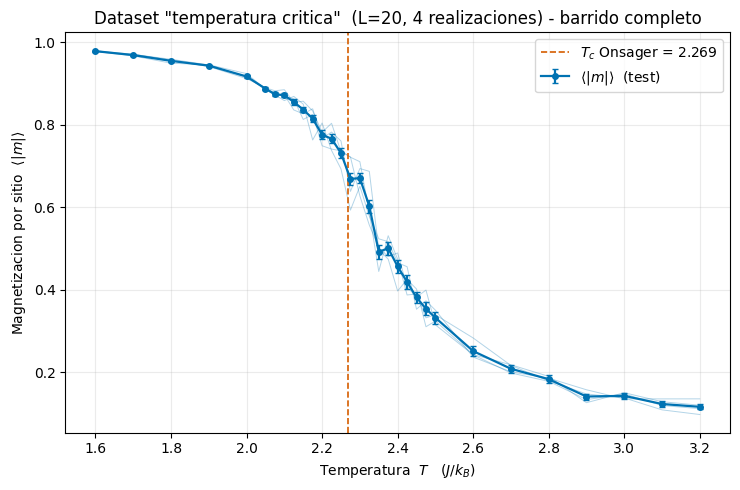

In [242]:
# ============================================================================
#  Dataset "temperatura critica"  ->  temperatura_critica.npz   (conjunto de TEST)
#  Barrido fino por TODAS las temperaturas (sin excluir la banda de T_c), con
#  varias realizaciones independientes. Se usa para localizar T_c: pasar las
#  configuraciones por la red ya entrenada y ver donde la salida media cruza
#  de "ordenada" a "desordenada".
# ============================================================================
L_tc = 16                   # debe COINCIDIR con el L del dataset de entrenamiento
n_realizaciones_tc = 4        # 3 o 4 realizaciones de test
n_config_por_T_tc = 50

temps_criticas = np.unique(np.concatenate([
    np.linspace(1.60, 2.00, 5),     # meseta ordenada
    np.linspace(2.05, 2.50, 19),    # zona critica, rejilla fina (paso ~0.025)
    np.linspace(2.60, 3.20, 7),     # meseta desordenada
]))

X_tc, T_tc, y_ref_tc, m_tc, r_tc = generar_dataset_ising(
    L=L_tc, temperaturas=temps_criticas,
    n_config_por_T=n_config_por_T_tc, n_realizaciones=n_realizaciones_tc,
    frontera='periodica', n_termalizacion=1500, barridos_entre_config=15,
    margen=0.0,                # <-- NINGUNA temperatura se excluye
    simetrizar=True, semilla=7,
)

nT = len(np.unique(T_tc))
print(f"\nX: {X_tc.shape}  dtype={X_tc.dtype}   ({X_tc.nbytes / 1024:.0f} KiB en memoria)")
print(f"{n_realizaciones_tc} realizaciones x {nT} temperaturas x {n_config_por_T_tc} configs = {len(T_tc)}")
print(f"rango de T: [{T_tc.min():.3f}, {T_tc.max():.3f}]   |   T_c(Onsager) = {TC_ONSAGER:.4f}")

ruta_tc = f'temperatura_critica{L_tc}.npz'
np.savez_compressed(
    ruta_tc, X=X_tc, T=T_tc, m=m_tc, realizacion=r_tc, y_ref=y_ref_tc,
    Tc=TC_ONSAGER, L=np.int64(L_tc), frontera='periodica',
)
print(f"guardado en: {ruta_tc}")

# --- comprobacion: <|m|>(T) por realizacion (tenue) y promedio (con error) ---
df_tc = pd.DataFrame({'T': T_tc, 'r': r_tc, 'm': m_tc})
prom = df_tc.groupby('T')['m'].agg(['mean', 'sem'])

fig, ax = plt.subplots(figsize=(7.5, 5))
for _, sub in df_tc.groupby('r'):
    s = sub.groupby('T')['m'].mean()
    ax.plot(s.index, s.values, '-', color='#0072B2', lw=0.7, alpha=0.3)
ax.errorbar(prom.index, prom['mean'], yerr=prom['sem'], fmt='o-', color='#0072B2',
            lw=1.6, ms=4, capsize=2, label=r'$\langle |m| \rangle$  (test)')
ax.axvline(TC_ONSAGER, color='#D55E00', ls='--', lw=1.2,
           label=fr'$T_c$ Onsager = {TC_ONSAGER:.3f}')
ax.set_xlabel(r'Temperatura  $T$   ($J/k_B$)')
ax.set_ylabel(r'Magnetizacion por sitio  $\langle |m| \rangle$')
ax.set_title(f'Dataset "temperatura critica"  (L={L_tc}, {n_realizaciones_tc} realizaciones) '
             f'- barrido completo')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
